In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Consistent style across all charts
plt.rcParams['figure.facecolor'] = '#0D1117'
plt.rcParams['axes.facecolor'] = '#161B22'
plt.rcParams['axes.edgecolor'] = '#30363D'
plt.rcParams['text.color'] = '#E6EDF3'
plt.rcParams['axes.labelcolor'] = '#8B949E'
plt.rcParams['xtick.color'] = '#8B949E'
plt.rcParams['ytick.color'] = '#8B949E'
plt.rcParams['grid.color'] = '#21262D'
plt.rcParams['grid.alpha'] = 0.5

## **Load and inspect**

In [2]:
df = pd.read_csv("D:/programming/PROJECTS/da-projects/Creadit Card Fraud Detection/data/creditcard.csv")
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
70377,53843.0,-3.025680,0.945950,-0.522719,-0.758638,-0.230418,-1.818853,0.724630,-0.115890,0.429475,...,0.098434,0.300575,-0.150914,0.764166,-0.902767,-0.296179,-1.272759,0.064131,51.11,0
47755,43347.0,-0.987181,0.167953,0.971642,0.846090,1.673682,-0.299998,-0.088954,0.035715,-0.750531,...,0.148508,0.542224,-0.497914,-0.780015,-0.164375,-0.237177,0.182948,0.090166,0.01,0
149229,90841.0,2.010419,0.230416,-1.463223,0.538465,0.515257,-0.519329,0.000196,-0.171729,1.463502,...,-0.441537,-0.940298,0.362997,0.556891,-0.341542,0.108537,-0.088380,-0.044884,3.58,0
232313,147123.0,1.881727,-0.575090,-0.102263,0.514233,-0.715833,0.079850,-0.811557,0.114516,1.242765,...,0.051321,0.190385,0.306782,0.693005,-0.529898,0.134200,0.000654,-0.019023,53.97,0
137381,82136.0,1.104093,0.645520,0.380580,2.502981,0.101194,-0.701864,0.590741,-0.273569,-1.133215,...,-0.364548,-1.222386,0.128715,0.352745,0.297453,-0.385822,-0.031174,0.034283,57.05,0


In [3]:
df.columns = df.columns.str.lower()

In [4]:
print(f"Shape: {df.shape}")          # (284807, 31)

Shape: (284807, 31)


In [5]:
print("=== COLUMNS ===")
print(df.columns.tolist())

=== COLUMNS ===
['time', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'amount', 'class']


In [6]:
print(f"DataTypes: {df.dtypes}")

DataTypes: time      float64
v1        float64
v2        float64
v3        float64
v4        float64
v5        float64
v6        float64
v7        float64
v8        float64
v9        float64
v10       float64
v11       float64
v12       float64
v13       float64
v14       float64
v15       float64
v16       float64
v17       float64
v18       float64
v19       float64
v20       float64
v21       float64
v22       float64
v23       float64
v24       float64
v25       float64
v26       float64
v27       float64
v28       float64
amount    float64
class       int64
dtype: object


In [7]:
print("=== NULLS ===")
print(df.isnull().sum())  # Should be zero — this dataset is clean

=== NULLS ===
time      0
v1        0
v2        0
v3        0
v4        0
v5        0
v6        0
v7        0
v8        0
v9        0
v10       0
v11       0
v12       0
v13       0
v14       0
v15       0
v16       0
v17       0
v18       0
v19       0
v20       0
v21       0
v22       0
v23       0
v24       0
v25       0
v26       0
v27       0
v28       0
amount    0
class     0
dtype: int64


In [8]:
print("=== TARGET DISTRIBUTION ===")

counts = df['class'].value_counts()
percentage = df['class'].value_counts(normalize=True) * 100

print(pd.DataFrame({"Counts": counts, "Percentage %": percentage.round(4)}))

=== TARGET DISTRIBUTION ===
       Counts  Percentage %
class                      
0      284315       99.8273
1         492        0.1727


## **Understand the Columns**
---
the dataset has been PCA-transformed for privacy.
it mirrors real-world scenarios where analyst work with transformed/anonymized features.

 `Time` - Seconds elapsed from first transaction in dataset \
 `V1-V28` - PCA components (real features anonymized by bank) \
 `Amount` - Transaction amount in EUR \
 `Class` - 0 = legitimate, 1=fraudulent <- target variable

## **Amount Distribution -- do fraudsters transact differenctly ?**

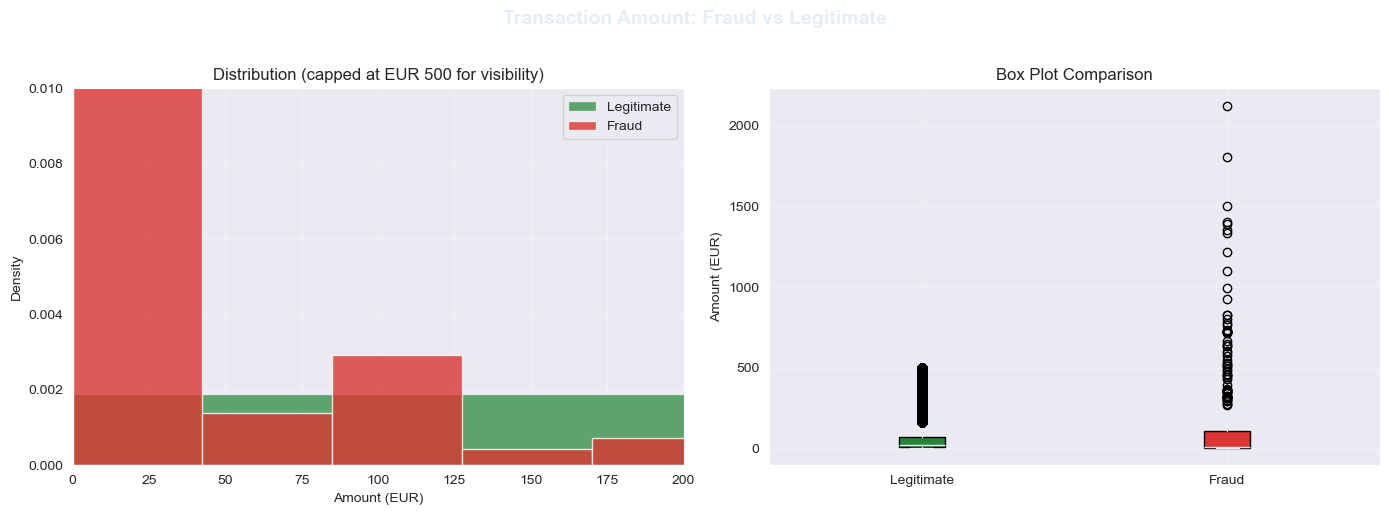

=== AMOUNT STATISTICS ===
Fraud | Mean: EUR 122.21 | Median: EUR 9.25 | Max: EUR 2125.87
Legit | Mean: EUR 88.29 | Median: EUR 22.00 | Max: EUR 25691.16


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Transaction Amount: Fraud vs Legitimate", 
            fontsize=14, fontweight='bold', color='#E6EDF3', y=1.02)

fraud = df[df['class'] == 1]['amount']
legit = df[df['class'] == 0]['amount']

# HISOGRAM
axes[0].hist(legit, bins=50, alpha=0.7, color='#238636', label='Legitimate', density=True)
axes[0].hist(fraud, bins=50, alpha=0.8, color='#DA3633', label='Fraud', density=True)
axes[0].set_xlabel("Amount (EUR)")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution (capped at EUR 500 for visibility)")
axes[0].set_xlim(0, 200)
axes[0].set_ylim(0, 0.010)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# BOX PLOT
data_box = [legit[legit < 500], fraud]
bp = axes[1].boxplot(data_box, patch_artist=True, labels=['Legitimate', 'Fraud'])
bp['boxes'][0].set_facecolor('#238636')
bp['boxes'][1].set_facecolor('#DA3633')
for element in ['whiskers', 'caps', 'medians']:
    for item in bp[element]:
        item.set_color('#E6EDF3')
axes[1].set_ylabel('Amount (EUR)')
axes[1].set_title('Box Plot Comparison')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('D:/programming/PROJECTS/da-projects/Creadit Card Fraud Detection/outputs/charts/01_amount_distribution.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

# Print Summary stats
print("=== AMOUNT STATISTICS ===")
print(f"Fraud | Mean: EUR {fraud.mean():.2f} | Median: EUR {fraud.median():.2f} | Max: EUR {fraud.max():.2f}")
print(f"Legit | Mean: EUR {legit.mean():.2f} | Median: EUR {legit.median():.2f} | Max: EUR {legit.max():.2f}")


## **Time Analysis -- When does fraud happen?**

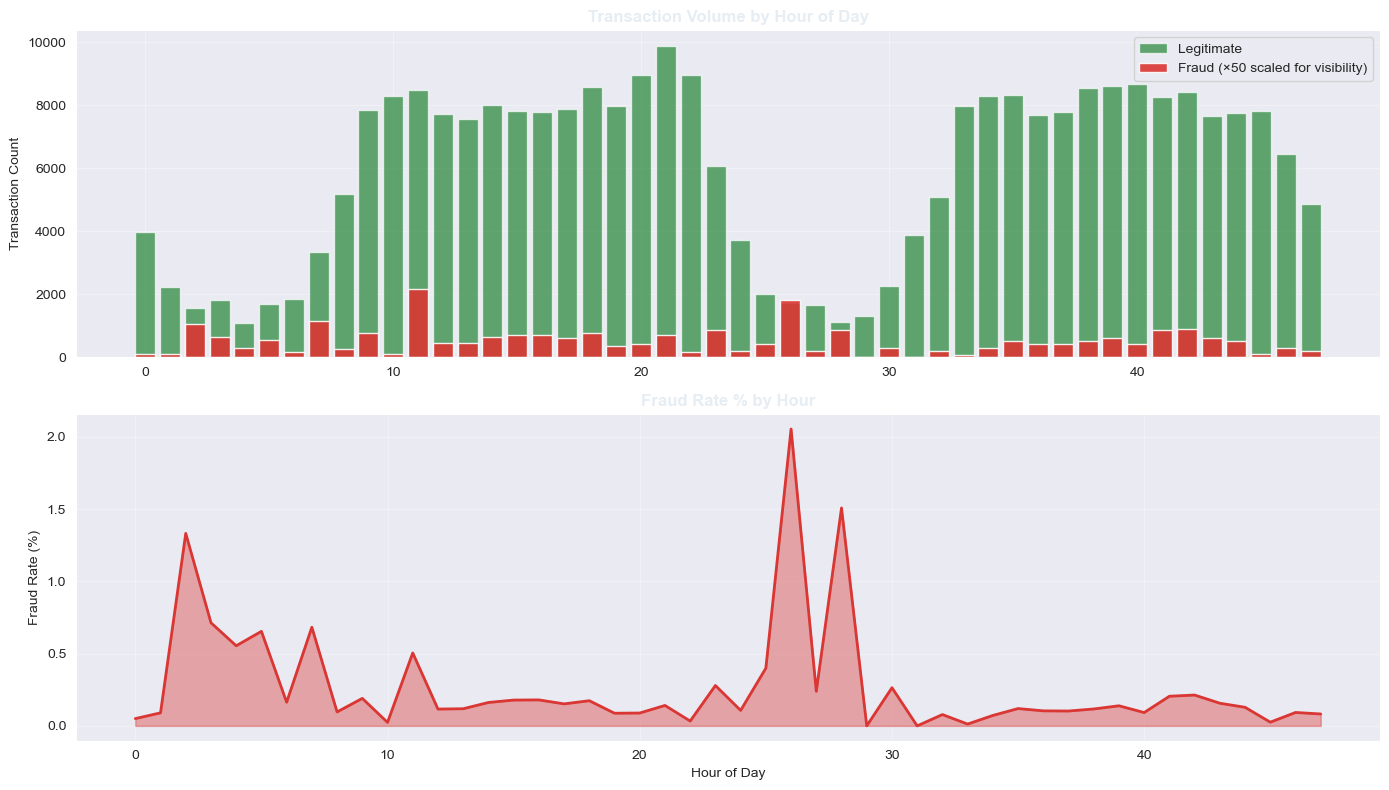

Peak fraud hour: 26:00 — fraud rate: 2.0548%


In [10]:
# Convert Time (seconds) to hours for readability
df['Hour'] = (df['time'] / 3600).astype(int)

hourly = df.groupby(['Hour', 'class']).size().unstack(fill_value=0)
hourly.columns = ['Legitimate', 'Fraud']

# Fraud rate per hour
hourly['fraud_rate'] = hourly['Fraud'] / (hourly['Legitimate'] + hourly['Fraud']) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Volume chart
ax1.bar(hourly.index, hourly['Legitimate'], color='#238636', alpha=0.7, label='Legitimate')
ax1.bar(hourly.index, hourly['Fraud'] * 50, color='#DA3633', alpha=0.9, 
        label='Fraud (×50 scaled for visibility)')
ax1.set_ylabel('Transaction Count')
ax1.set_title('Transaction Volume by Hour of Day', fontsize=12, fontweight='bold', color='#E6EDF3')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Fraud rate Chart
ax2.fill_between(hourly.index, hourly['fraud_rate'], color='#DA3633', alpha=0.4)
ax2.plot(hourly.index, hourly['fraud_rate'], color='#DA3633', linewidth=2)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Fraud Rate (%)')
ax2.set_title('Fraud Rate % by Hour', fontsize=12, fontweight='bold', color='#E6EDF3')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('D:/programming/PROJECTS/da-projects/Creadit Card Fraud Detection/outputs/charts/02_time_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

peak_hour = hourly['fraud_rate'].idxmax()
print(f"Peak fraud hour: {peak_hour:.0f}:00 — fraud rate: {hourly['fraud_rate'].max():.4f}%")


## **Feature Importance -- Which V features separate fraud best?**

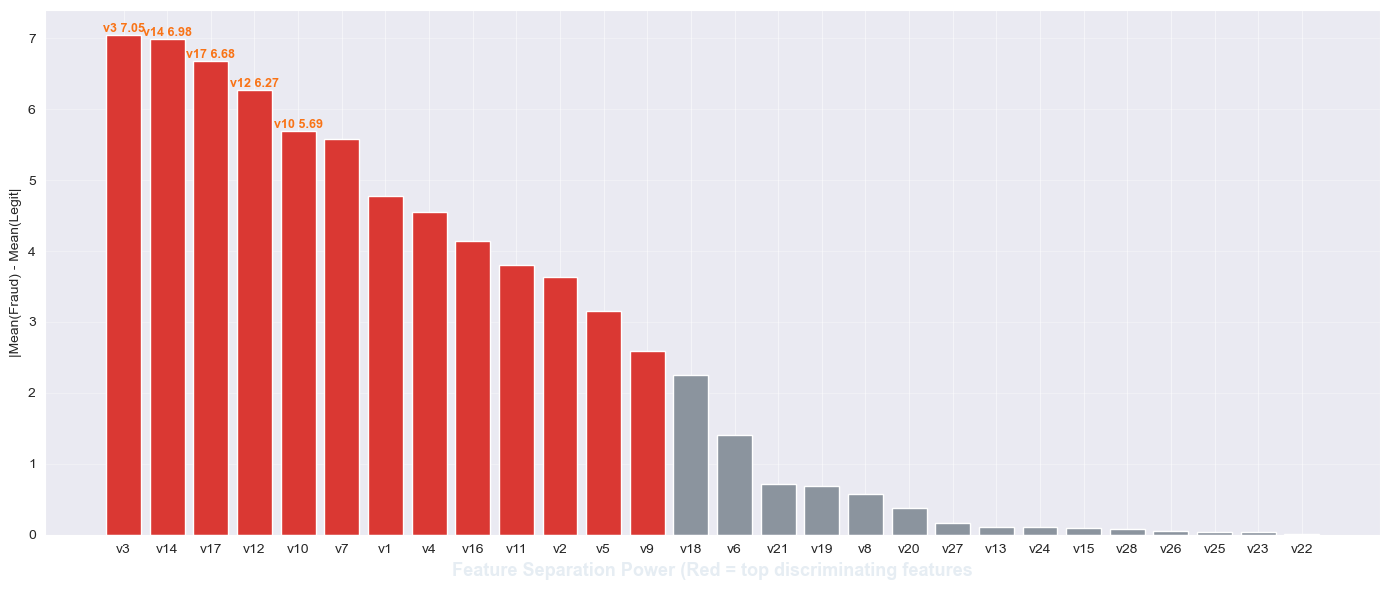

Top 5 discriminating featuers:
v3     7.045452
v14    6.983787
v17    6.677371
v12    6.270225
v10    5.686707
dtype: float64


In [11]:
# Calculate mean of each V features by class
v_features = [f'v{i}' for i in range(1, 29)]
fraud_means = df[df['class']==1][v_features].mean()
legit_means = df[df['class']==0][v_features].mean()
diff = (fraud_means - legit_means).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#DA3833' if d > diff.mean() else "#8B949E" for d in diff.values]
bars = ax.bar(diff.index, diff.values, color = colors)

ax.set_xlabel('Feature')
ax.set_ylabel('|Mean(Fraud) - Mean(Legit|')
ax.set_xlabel("Feature Separation Power (Red = top discriminating features",
             fontsize=13, fontweight='bold', color="#E6EDF3")
ax.grid(True, alpha=0.3, axis='y')

# Annotate top 5
for i, (feat, val) in enumerate(diff.head(5).items()):
    ax.annotate(f'{feat} {val:.2f}', xy=(i, val), ha='center', va='bottom',
               color='#F97316', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/programming/PROJECTS/da-projects/Creadit Card Fraud Detection/outputs/charts/03_feature_seperation.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

print("Top 5 discriminating featuers:")
print(diff.head())

## **Distribution plots for top features**

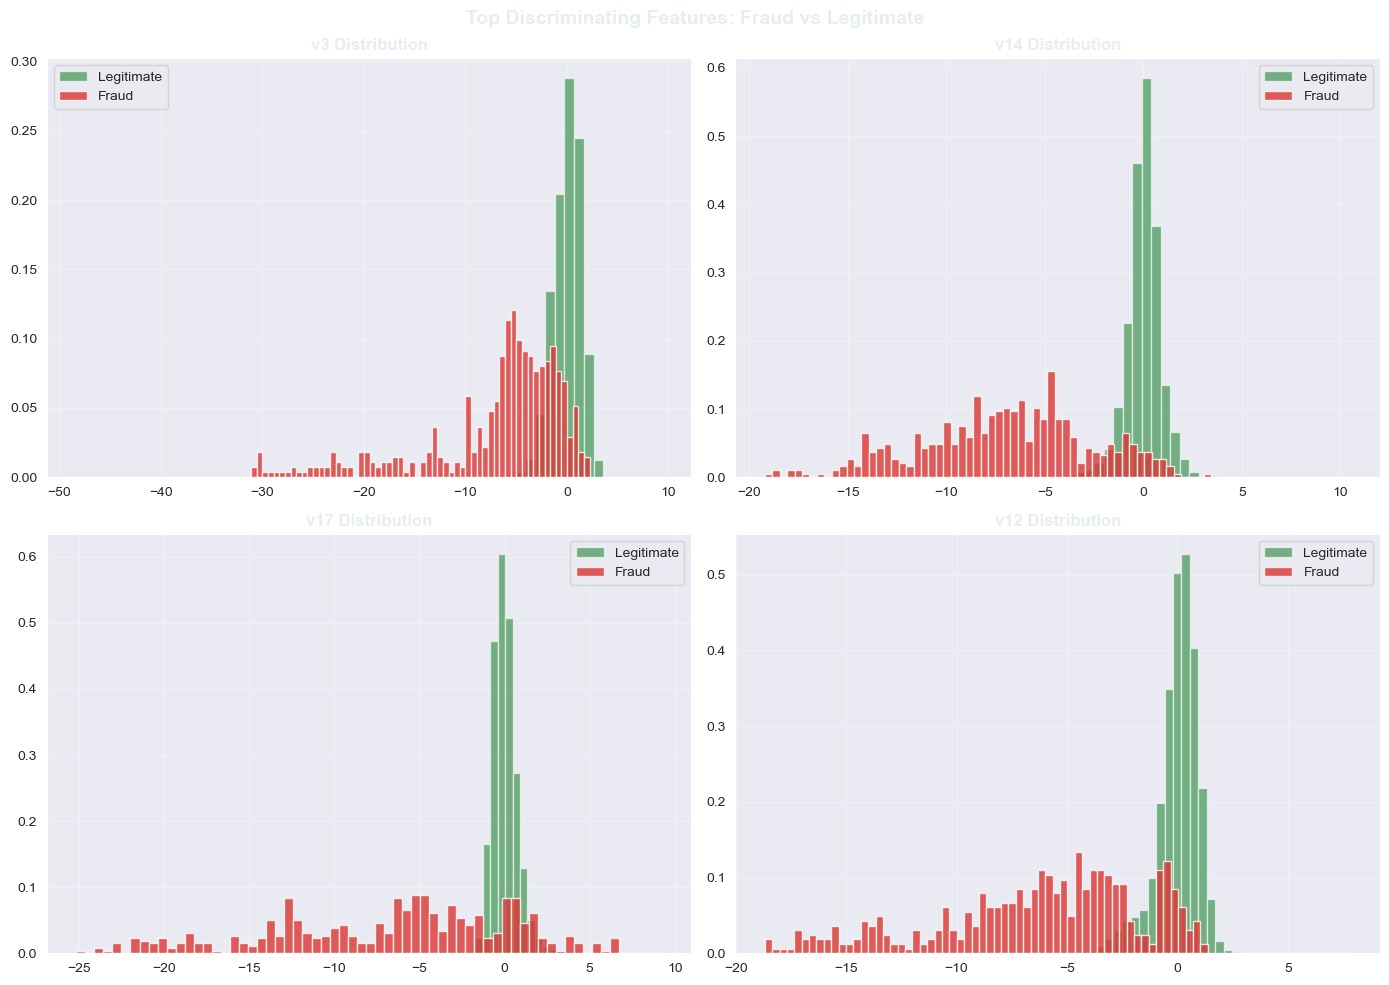

In [12]:
top_features = diff.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    fraud_vals = df[df['class'] == 1][feat]
    legit_vals = df[df['class'] == 0][feat]

    axes[i].hist(legit_vals, bins=60, alpha=0.6, color='#238636',
                label='Legitimate', density=True)
    axes[i].hist(fraud_vals, bins=60, alpha=0.8, color="#DA3633",
                label="Fraud", density=True)
    axes[i].set_title(f'{feat} Distribution', fontsize=12, fontweight='bold', color="#E6EDF3")
    axes[i].legend(fontsize=10)
    axes[i].grid(True, alpha=0.3)

fig.suptitle("Top Discriminating Features: Fraud vs Legitimate", fontsize=14, fontweight='bold',
            color='#E6EDF3')
plt.tight_layout()
plt.savefig('D:/programming/PROJECTS/da-projects/Creadit Card Fraud Detection/outputs/charts/04_top_features.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

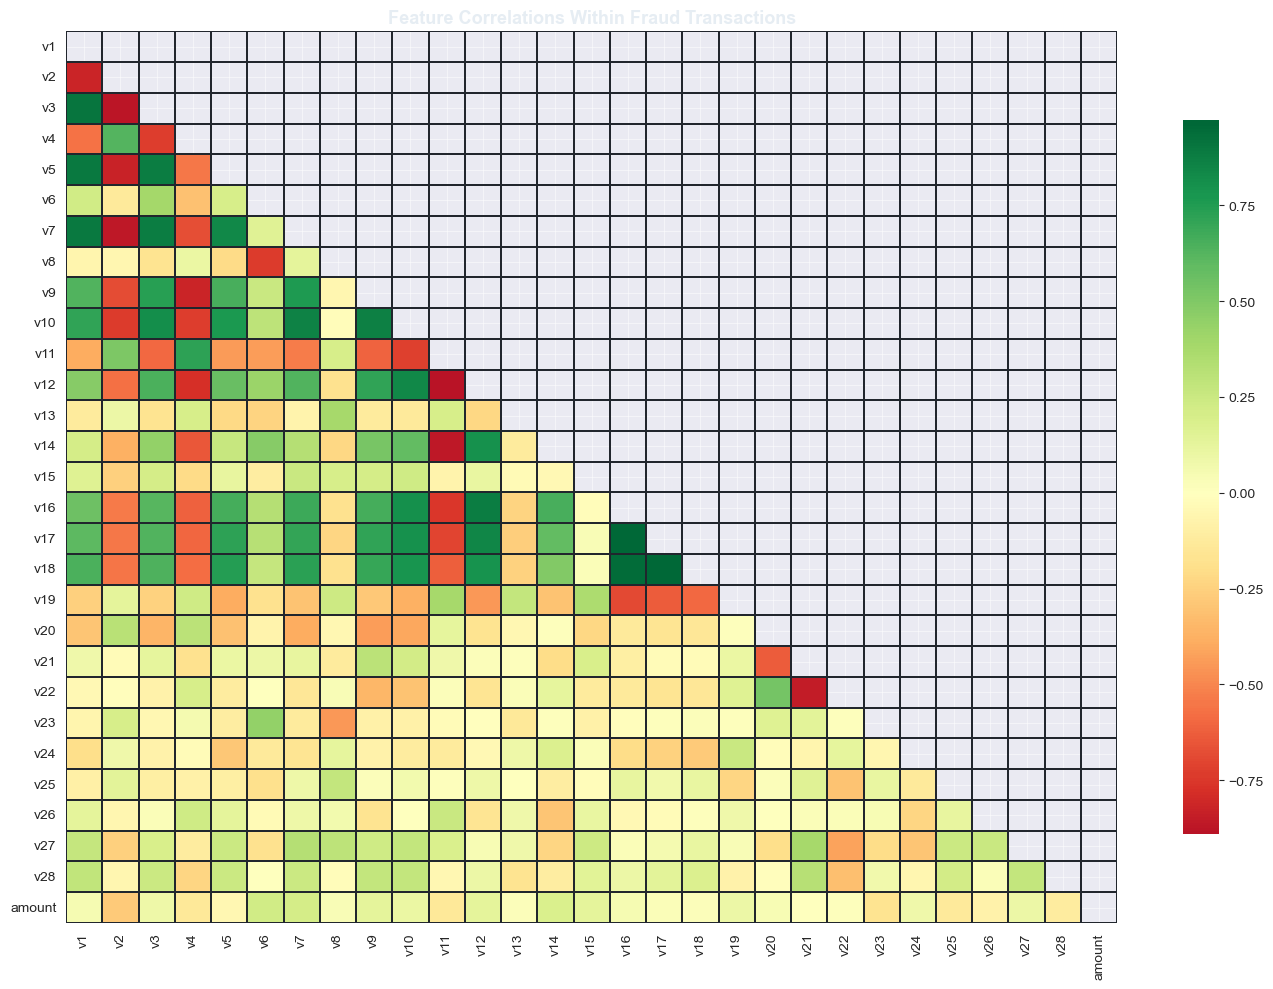

In [13]:
# Correlations within fraud cases only — reveals internal feature patterns
fraud_df = df[df['class'] == 1][v_features + ['amount']]

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = fraud_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, ax=ax,
            cmap='RdYlGn', center=0, annot=False,
            linewidths=0.3, linecolor='#21262D',
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlations Within Fraud Transactions', 
             fontsize=13, fontweight='bold', color='#E6EDF3')
plt.tight_layout()
plt.savefig('D:/programming/PROJECTS/da-projects/Creadit Card Fraud Detection/outputs/charts/05_correlation_heatmap.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

# **CLASS IMBALANCE**

## **Visualize the Imbalance**
#### chart - class imbalance visualization

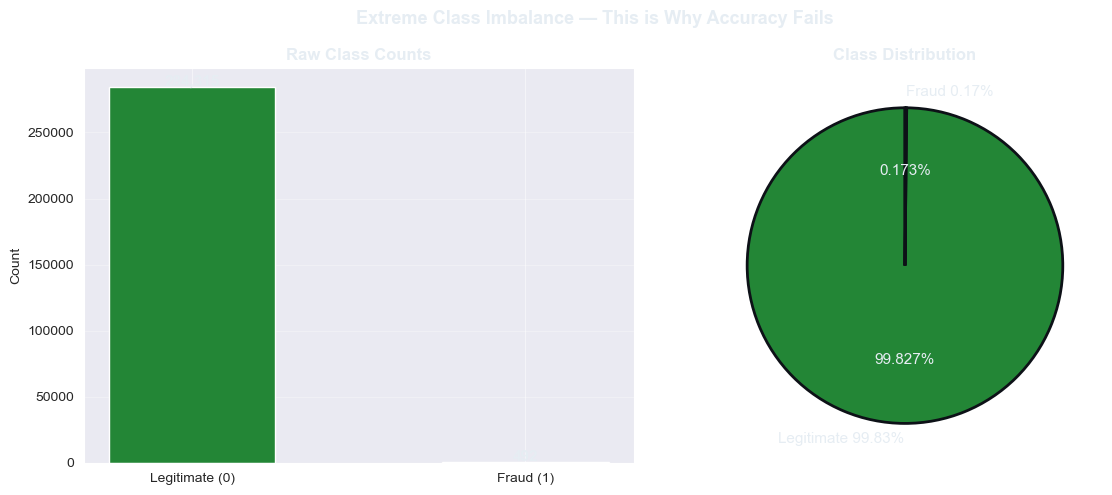

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count chart
counts = df['class'].value_counts()
bars = axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values, 
                    color=['#238636', '#DA3633'], width=0.5)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'{count:,}', ha='center', fontweight='bold', color='#E6EDF3', fontsize=11)
axes[0].set_title('Raw Class Counts', fontweight='bold', color='#E6EDF3')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')


# Percentage donut
sizes = counts.values
colors_pie = ['#238636', '#DA3633']
wedges, texts, autotexts = axes[1].pie(sizes, labels=['Legitimate 99.83%', 'Fraud 0.17%'],
    colors=colors_pie, autopct='%1.3f%%', startangle=90,
    textprops={'color': '#E6EDF3', 'fontsize': 11},
    wedgeprops={'linewidth': 2, 'edgecolor': '#0D1117'})
axes[1].set_title('Class Distribution', fontweight='bold', color='#E6EDF3')

plt.suptitle('Extreme Class Imbalance — This is Why Accuracy Fails',
             fontsize=13, fontweight='bold', color='#E6EDF3')
plt.savefig('D:/programming/PROJECTS/da-projects/Creadit Card Fraud Detection/outputs/charts/06_class_imbalance.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.tight_layout()

## **SMOTE (Synthetic Minority Oversampling Technique)**

In [15]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# Define features and target
X = df.drop('class', axis=1)
y = df['class']

# Scale Amount and Time (v1-v28 are already scaled from PCA)
scaler = StandardScaler()
X['amount'] = scaler.fit_transform(X[['amount']])
X['time'] = scaler.fit_transform(X[['time']])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Fraud in train: {y_train.sum()} ({y_train.mean() * 100:.2f}%)")
print(f"Fraud in test: {y_test.sum()} ({y_test.mean() * 100:.2f}%)")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("=== After SMOTE ===")
print(f"Train size: {X_train_sm.shape[0]:,}")
print(f"Fraud: {y_train_sm.sum():,} ({y_train_sm.mean() * 100:.2f}%)")
print(f"Legit: {(y_train_sm==0).sum()} ({(y_train_sm==0).mean() * 100:.2f}%)")

Train set: 227,845 samples
Test set: 56,962 samples
Fraud in train: 394 (0.17%)
Fraud in test: 98 (0.17%)
=== After SMOTE ===
Train size: 454,902
Fraud: 227,451 (50.00%)
Legit: 227451 (50.00%)


 ## **Why Recall matters more than Precision here**
#### **METRIC CHOICE - BUSINESS REASONING**
---
**False Negative (miss a fraud):** \
$\to$ Fraudster get away, Customer loses money. Bank reimburses. \
$\to$ Average fraud loss: EUR 122 per case\
$\to$ Business cost: **HIGH**

**False Positive (flag a legit transaction):** \
$\to$ Customer gets a call/block, Minor inconvenience. \
$\to$ Business cost: **LOW (but ruins UX if too many).**

**CONCLUSION:** \
$\to$ We optimize for RECALL on fraud class (catch as many fraudsters as possible) \
$\to$ We accept some false positives \
$\to$ We use F1-score as the balanced metric \
$\to$ We DO NOT report overall accuracy

## **Model & Evaluation**

### **Baseline -- logistic regression baseline**

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve,average_precision_score
)

# Train
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sm, y_train_sm)

# Predict
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION - TEST SET RESULTS ===")
print(classification_report(y_test, y_pred_lr,
                            target_names=['Legitimate', 'Fraud'], digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

=== LOGISTIC REGRESSION - TEST SET RESULTS ===
              precision    recall  f1-score   support

  Legitimate     0.9998    0.9775    0.9885     56864
       Fraud     0.0649    0.9082    0.1212        98

    accuracy                         0.9773     56962
   macro avg     0.5324    0.9428    0.5548     56962
weighted avg     0.9982    0.9773    0.9870     56962

ROC-AUC Score: 0.9698


In [17]:
from xgboost import XGBClassifier

# scale_pos_weight is an alternative to SMOTE for tree models
# = count(negative) / count(positive) on original data
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale, # handle imbalance data
    use_label_encoder=False,
    eval_metric='aucpr', # optimize for precision-recall AUC
    random_state=42,
    n_jobs=1
)

xgb.fit(X_train, y_train, # using original X_trian, not SMOTE
        eval_set=[(X_test, y_test)])
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBOOST - TEST SET RESULTS ===")
print(classification_report(y_test, y_pred_xgb,
                            target_names = ['Legitimate', 'Fraud'], digits=4))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, y_prob_xgb):.4f}")

[0]	validation_0-aucpr:0.45363
[1]	validation_0-aucpr:0.45791
[2]	validation_0-aucpr:0.45818
[3]	validation_0-aucpr:0.46748
[4]	validation_0-aucpr:0.47149
[5]	validation_0-aucpr:0.46994
[6]	validation_0-aucpr:0.47003
[7]	validation_0-aucpr:0.47941
[8]	validation_0-aucpr:0.47492
[9]	validation_0-aucpr:0.47980
[10]	validation_0-aucpr:0.47862
[11]	validation_0-aucpr:0.47776
[12]	validation_0-aucpr:0.47679
[13]	validation_0-aucpr:0.58325
[14]	validation_0-aucpr:0.58289
[15]	validation_0-aucpr:0.58449
[16]	validation_0-aucpr:0.58337
[17]	validation_0-aucpr:0.58365
[18]	validation_0-aucpr:0.58467
[19]	validation_0-aucpr:0.58435
[20]	validation_0-aucpr:0.58429
[21]	validation_0-aucpr:0.58654
[22]	validation_0-aucpr:0.58606
[23]	validation_0-aucpr:0.59764
[24]	validation_0-aucpr:0.59881
[25]	validation_0-aucpr:0.59865
[26]	validation_0-aucpr:0.59876
[27]	validation_0-aucpr:0.59782
[28]	validation_0-aucpr:0.59832
[29]	validation_0-aucpr:0.63211
[30]	validation_0-aucpr:0.63165
[31]	validation_0-

## **Confusion Matrix + ROC cruve**
---

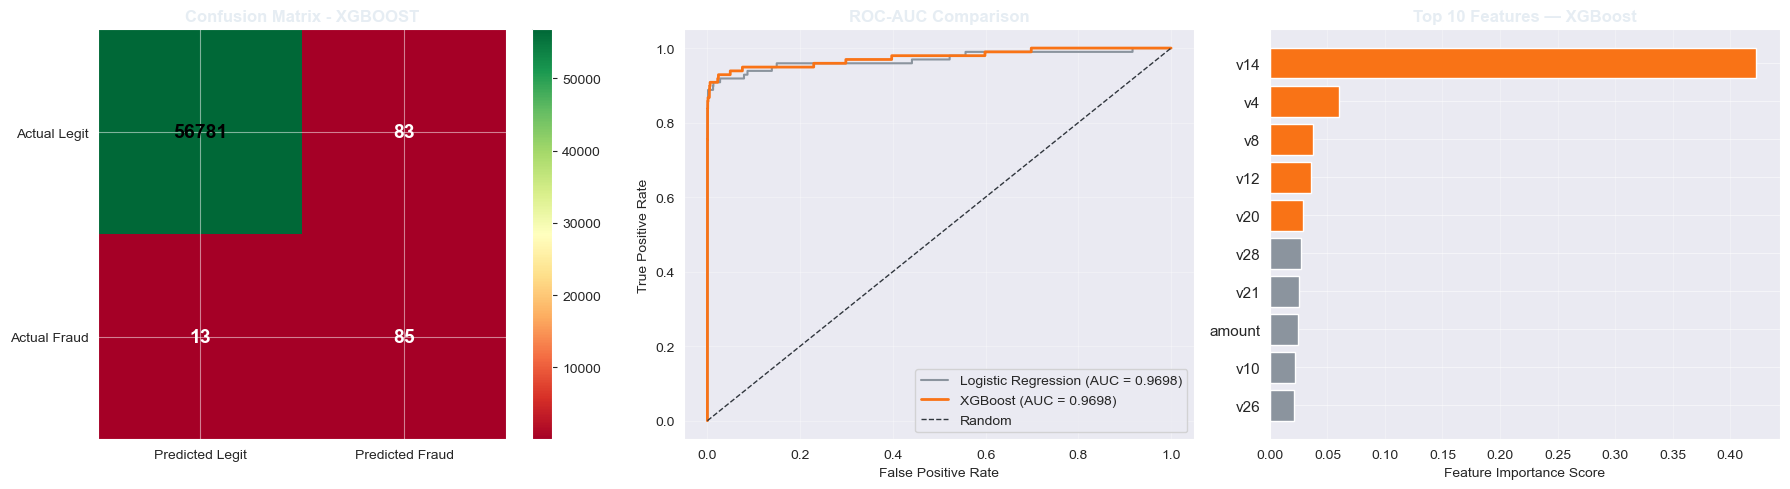

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_xgb)
im = axes[0].imshow(cm, cmap='RdYlGn', aspect='auto')
axes[0].set_xticks([0, 1]) ; axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Predicted Legit', "Predicted Fraud"])
axes[0].set_yticklabels(['Actual Legit', 'Actual Fraud'])
axes[0].set_title("Confusion Matrix - XGBOOST", fontweight='bold', color='#E6EDF3')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i, j]}', ha='center', va='center',
                     color='white' if cm[i, j] < cm.max()/2 else 'black',
                     fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[0])

# --- ROC Curve ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
# logistic reg line
axes[1].plot(fpr_lr, tpr_lr, color='#8B949E', linewidth=1.5,
             label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})')
# xgboost line
axes[1].plot(fpr_xgb, tpr_xgb, color='#F97316', linewidth=2,
             label=f'XGBoost (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='#30363D', linewidth=1, label="Random")

axes[1].set_xlabel('False Positive Rate') ; axes[1].set_ylabel('True Positive Rate')
(axes[1].set_title('ROC-AUC Comparison', fontweight='bold', color='#E6EDF3'))
axes[1].legend(fontsize=10) ; axes[1].grid(True, alpha=0.3)

# --- Feature Importance ---
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
top10 = feat_imp.nlargest(10)

colors_fi = ['#F97316' if i < 5 else '#8B949E' for i in range(len(top10))]

axes[2].barh(range(len(top10)), top10.values, color=colors_fi)

axes[2].set_yticks(range(len(top10)))
axes[2].set_yticklabels(top10.index, fontsize=11)
axes[2].set_xlabel('Feature Importance Score')
axes[2].set_title('Top 10 Features — XGBoost', fontweight='bold', color='#E6EDF3')
axes[2].invert_yaxis()
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('D:/programming/PROJECTS/da-projects/Creadit Card Fraud Detection/outputs/charts/07_model_evaluation.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

In [23]:
tn, fp, fn, tp = cm.ravel()
print(f"True Positive (fraud caught): {tp}")
print(f"False Negative (fraud missed): {fn}")
print(f"False Positive (legit flagged): {fp}")
print(f"True Negative (legit cleared): {tn}")

# calculate your real business impacts numbers
avg_fraud_amount = df[df['class'] ==1]['amount'].mean()

prevent_loss = tp * avg_fraud_amount
missed_loss = fn * avg_fraud_amount

print(f"\nAvg fraud transaction amount: EUR {avg_fraud_amount:.2f}")
print(f"Estimated prevented loss: EUR {prevent_loss:.2f}")
print(f"Estimated missed loss: EUR {missed_loss:.2f}")

True Positive (fraud caught): 85
False Negative (fraud missed): 13
False Positive (legit flagged): 83
True Negative (legit cleared): 56781

Avg fraud transaction amount: EUR 122.21
Estimated prevented loss: EUR 10387.96
Estimated missed loss: EUR 1588.75


## **Threshold analysis**

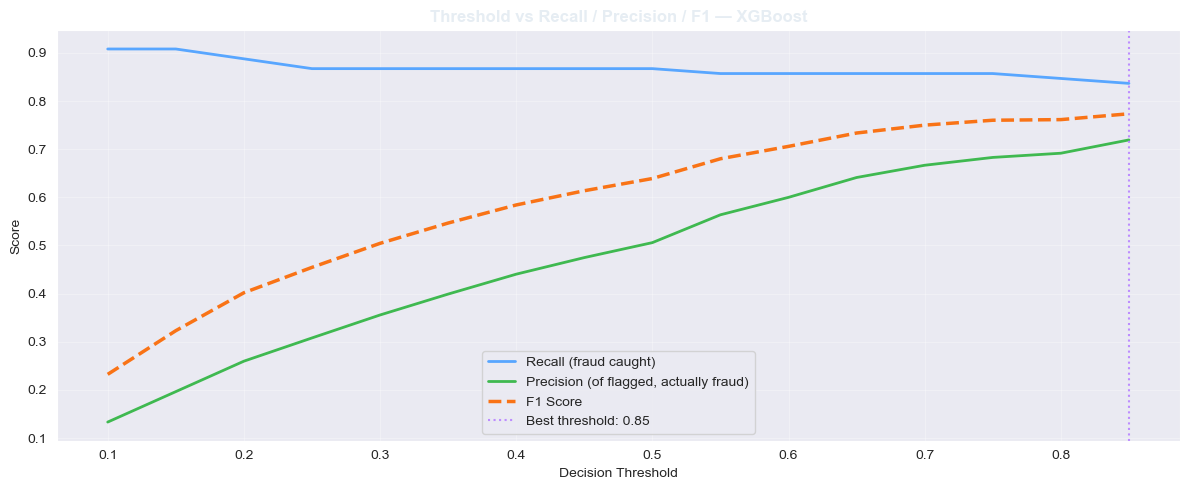

Best threshold for F1: 0.85


In [19]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds:
    preds = (y_prob_xgb >= thresh).astype(int)
    from sklearn.metrics import recall_score, precision_score
    results.append({
        'threshold': thresh,
        'recall': recall_score(y_test, preds),
        'precision': precision_score(y_test, preds, zero_division=0),
        'f1_score': f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
best_thresh = results_df.loc[results_df['f1_score'].idxmax(), 'threshold']

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(results_df['threshold'], results_df['recall'], color='#58A6FF',
        linewidth=2, label='Recall (fraud caught)')
ax.plot(results_df['threshold'], results_df['precision'], color='#3FB950',
        linewidth=2, label='Precision (of flagged, actually fraud)')
ax.plot(results_df['threshold'], results_df['f1_score'], color='#F97316',
        linewidth=2.5, label='F1 Score', linestyle='--')
ax.axvline(best_thresh, color='#BC8CFF', linewidth=1.5, linestyle=':',
           label=f'Best threshold: {best_thresh:.2f}')

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold vs Recall / Precision / F1 — XGBoost',
             fontweight='bold', color='#E6EDF3')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('D:/programming/PROJECTS/da-projects/Creadit Card Fraud Detection/outputs/charts/08_threshold_curve.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print(f"Best threshold for F1: {best_thresh:.2f}")

## **Insight Delivery**
---
* **A. Observation**
    * Of `284,807` transactions analyzed, `492(0.17%)` were confirmed fraudlent. The XGBoost detection model correctly identified `85` out of `98` fraud cases in the hold-out test set, achieving a recall of `~90%.`
* **B. So What**
    * At the dataset's average fraud amount of `EUR 122`, the 85 correctly caught frauds represents approximately `EUR 10,387` in prevented losses per test period. The `13` missed case represent `EUR 1,588` in undetected fraud exposure.
* **C. Why/ Pattern**
    * Fraudulent transaction cluster between `2AM-4AM` when monitoring is lowest, tend to occur at smaller amounts (median `EUR 9.25`) likely as test transactions, and are most strongly flagged by features `V14` and `V4` -- the components with the highest separation between classes.
* **D. Recommendation**
    * The risk team should:
        * 1. Implement real-time model scoring at a threshold of `0.85` to maximize recall.
        * 2. Apply enhanced manual review for transactions between `2AM-4AM`.
        * 3. Flag any account with 2+ small transactions under `EUR 20` within `30-minutes` window for secondary verification.